In [20]:
## DL Tools
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

## data management
import numpy as np
from scipy.stats import stats
import pandas as pd

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import time




In [21]:
import opendatasets as od

In [22]:
#od.download("https://www.kaggle.com/datasets/dskagglemt/uci-wine-quality-dataset")

In [23]:
data = pd.read_csv("uci-wine-quality-dataset/winequality-red.csv", sep=";")
data.tail(5)
type(data)

pandas.core.frame.DataFrame

In [24]:
### describe the data
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [25]:
data.keys()

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [26]:
## list the number of unique values per every column
for i in data.keys():
    print(f" {i } has unique values {len(data[i].unique())}")

 fixed acidity has unique values 96
 volatile acidity has unique values 143
 citric acid has unique values 80
 residual sugar has unique values 91
 chlorides has unique values 153
 free sulfur dioxide has unique values 60
 total sulfur dioxide has unique values 144
 density has unique values 436
 pH has unique values 89
 sulphates has unique values 96
 alcohol has unique values 65
 quality has unique values 6


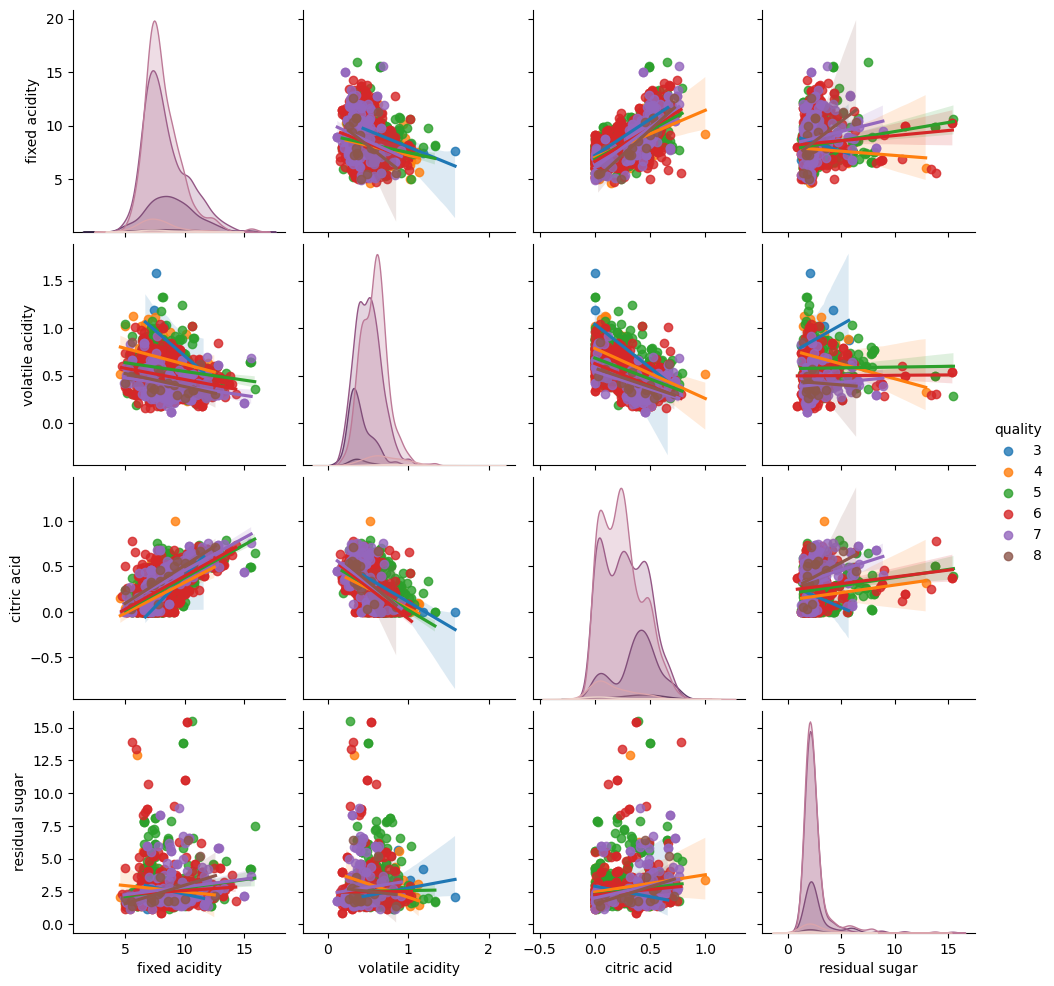

In [27]:
## visualize pairplots 
cols_to_plot = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', "quality"]
sns.pairplot(data[cols_to_plot], hue="quality", kind="reg")

<Axes: >

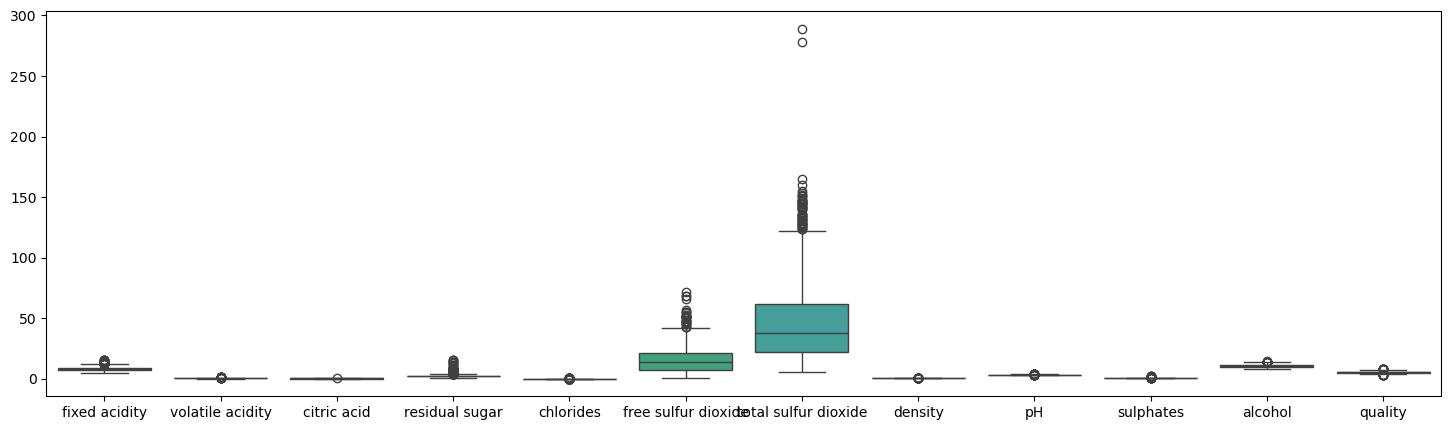

In [28]:
fig, ax = plt.subplots(1, figsize=(18, 5))
sns.boxplot(data=data, ax=ax)

In [29]:
### Removing the two outliers in total sulphur dioxide
print(data["total sulfur dioxide"].max())
data = data[data["total sulfur dioxide"] < 200]
print(data["total sulfur dioxide"].max())

289.0
165.0


<Axes: >

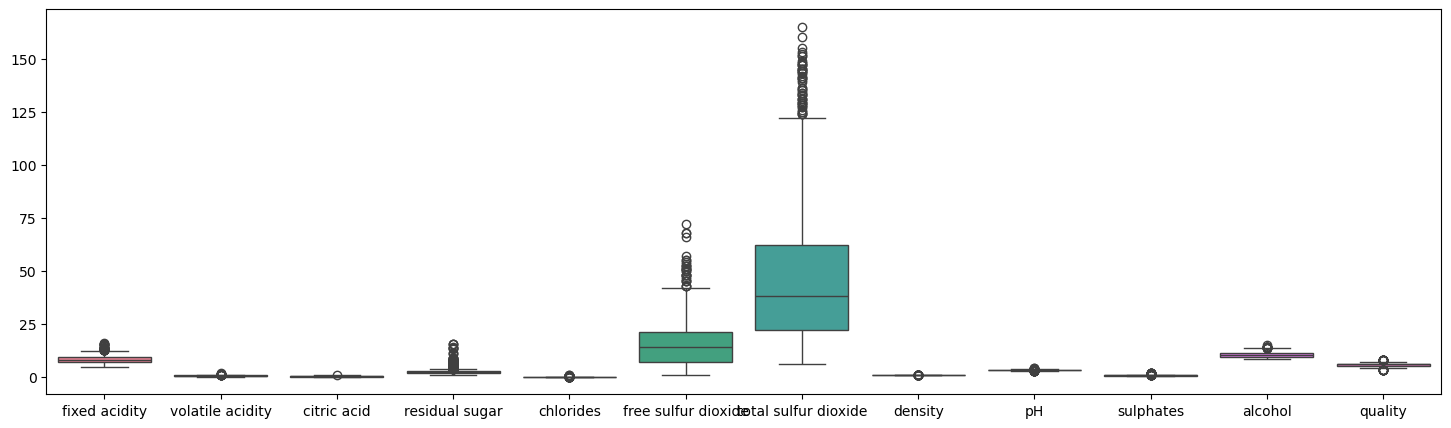

In [30]:
fig, ax = plt.subplots(1, figsize=(18, 5))
sns.boxplot(data=data, ax=ax)

In [31]:
col_to_zscore = data.keys()
col_to_zscore = col_to_zscore.drop("quality")

for col in col_to_zscore:
    mean_val = np.mean(data[col])
    stdev = np.std(data[col], ddof=1)
    data[col] = ((data[col])-mean_val)/ stdev
    

## A shorthand to do this
#data[col_to_zscore] = data[col_to_zscore].apply(stats.zscore)

In [32]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1597.000000
mean,7.118775e-17,1.201293e-16,5.339081e-17,-7.118775e-17,-1.512740e-16,1.779694e-17,-7.118775e-17,-8.350323e-14,2.847510e-16,1.067816e-16,-6.050959e-16,5.634314
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.806630
min,-2.135419e+00,-2.280048e+00,-1.391387e+00,-1.168783e+00,-1.604073e+00,-1.422392e+00,-1.262186e+00,-3.545821e+00,-3.708218e+00,-1.936711e+00,-1.898626e+00,3.000000
25%,-7.003882e-01,-7.715838e-01,-9.283861e-01,-4.524372e-01,-3.720247e-01,-8.476045e-01,-7.594598e-01,-6.109478e-01,-6.585382e-01,-6.390204e-01,-8.650444e-01,5.000000
50%,-2.411785e-01,-4.528645e-02,-5.382836e-02,-2.375335e-01,-1.808448e-01,-1.770192e-01,-2.567340e-01,-6.214425e-04,-9.670044e-03,-2.261189e-01,-2.073106e-01,6.000000
75%,5.050372e-01,6.251419e-01,7.692848e-01,4.900487e-02,5.281955e-02,4.935662e-01,4.973546e-01,5.778618e-01,5.743113e-01,4.227263e-01,6.383472e-01,6.000000
max,4.350918e+00,5.876831e+00,3.753070e+00,9.289866e+00,1.112001e+01,5.379259e+00,3.733652e+00,3.682565e+00,4.532407e+00,7.913939e+00,4.208902e+00,8.000000


<Axes: >

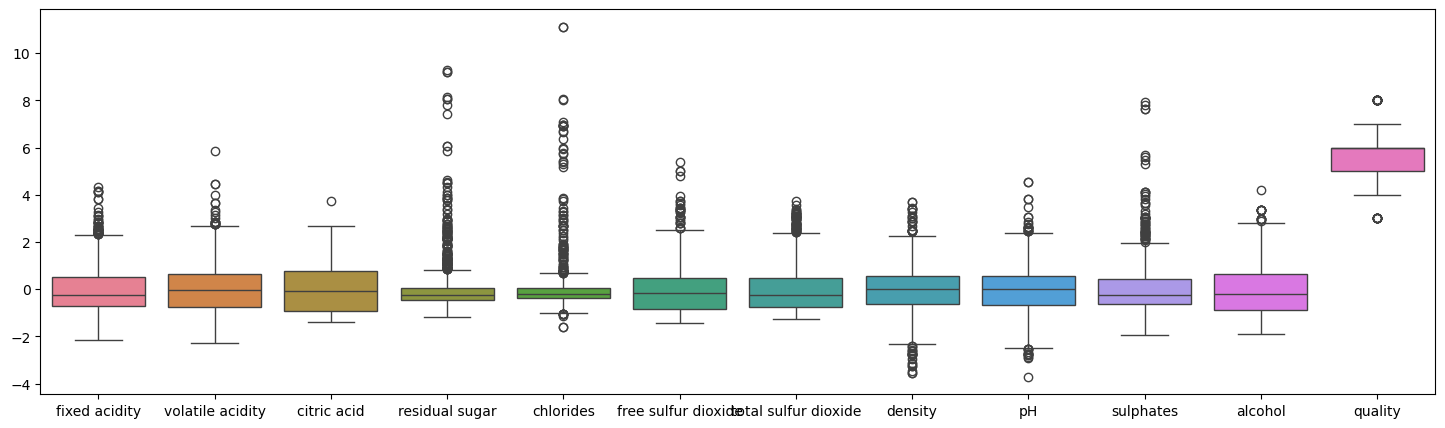

In [33]:
fig, ax = plt.subplots(1, figsize=(18, 5))
sns.boxplot(data=data, ax=ax)

In [34]:
quality_counts=data['quality'].value_counts()
quality_counts

quality
5    681
6    638
7    197
4     53
8     18
3     10
Name: count, dtype: int64

Text(0, 0.5, 'counts')

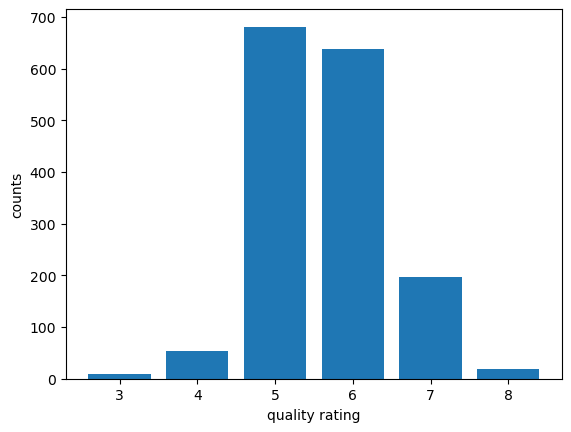

In [35]:
plt.bar(x=quality_counts.index, height=quality_counts.values)
plt.xlabel("quality rating")
plt.ylabel("counts")

In [36]:
data["boolQuality"] = data["quality"].apply(lambda x: 1 if x>5 else 0 )

In [37]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,boolQuality
0,-0.528185,0.960356,-1.391387,-0.452437,-0.244571,-0.464413,-0.382415,0.556633,1.288066,-0.580034,-0.959006,5,0
1,-0.298580,1.965999,-1.391387,0.049005,0.222757,0.876758,0.654456,0.025914,-0.723425,0.127797,-0.583159,5,0
2,-0.298580,1.295570,-1.185609,-0.165899,0.095304,-0.081221,0.245992,0.132058,-0.334104,-0.049161,-0.583159,5,0
3,1.653061,-1.386143,1.489509,-0.452437,-0.265814,0.110375,0.434514,0.662777,-0.982972,-0.462063,-0.583159,6,1
4,-0.528185,0.960356,-1.391387,-0.452437,-0.244571,-0.464413,-0.382415,0.556633,1.288066,-0.580034,-0.959006,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.216999,0.401666,-0.979831,-0.380803,0.052820,1.547343,-0.068212,-0.982451,0.898745,-0.462063,0.074575,5,0
1595,-1.389203,0.122321,-0.876942,-0.237533,-0.541962,2.217928,0.151731,-0.865693,1.352953,0.599684,0.732309,6,1
1596,-1.159598,-0.101155,-0.722608,-0.165899,-0.244571,1.259949,-0.193893,-0.536647,0.704085,0.540698,0.544385,6,1
1597,-1.389203,0.653076,-0.774052,-0.380803,-0.265814,1.547343,-0.068212,-0.679941,1.677387,0.304754,-0.207311,5,0


In [38]:
## Convert from Numpy to Tensors
featuresT = torch.tensor(data[col_to_zscore].values, dtype=torch.float32)
labelsT = torch.tensor(data["boolQuality"].values, dtype=torch.float32).unsqueeze(dim=1)

print(featuresT.shape)
print(labelsT.shape)
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.Size([1597, 11])
torch.Size([1597, 1])


In [39]:
train_data, test_data, train_labels, test_labels = train_test_split(featuresT, labelsT,test_size=0.1, random_state=42 )

In [40]:
train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(test_data, batch_size=32 )



In [41]:
class WineNet(nn.Module):
    def __init__(self):
        super().__init__( )
        ##Input layer
        self.input= nn.Linear(in_features=11, out_features=16 )
        
        #hidden layers
        self.layer2 = nn.Linear(in_features=16, out_features=32)
        self.layer3 = nn.Linear(in_features=32, out_features=32 )
        self.layer4 = nn.Linear(in_features=32, out_features=16)
        
        #output layer
        self.output = nn.Linear(in_features=16, out_features=1)
        
        
    def forward(self, x):
        x= F.relu(self.input(x))
        x= F.relu(self.layer2(x))
        x= F.relu(self.layer3(x))
        x= F.relu(self.layer4(x))
        x = self.output(x)
        return x
        
      

In [42]:
from torchmetrics.classification import BinaryAccuracy


In [43]:
x, y = next(iter(train_loader))
print(x.dtype, y.dtype)

torch.float32 torch.float32


In [ ]:
def evaluate_function(model, dataloader, metric, device, lossfunc):
    model.eval() ##put model in evaluation mode
    metric.reset() ##reset the metrics
    total_loss = 0.0    
    with torch.no_grad(): #disable gradient tracking, for evaluation
        for x_batch, y_batch in dataloader: 
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            ##forward pass
            logits = model(x_batch)
            probs = torch.sigmoid(logits)
            test_loss = lossfunc(probs, y_batch)
            total_loss += test_loss.item()
            metric.update(probs, y_batch)
        total_loss /= total_loss/len(dataloader)
            
            
    return metric.compute().item(), total_loss
            
def train_model(model, metric, loss_fn, optimizer, train_loader, valid_loader, epochs, device):
    
    history = {
        "train_loss": [],
        "train_metrics": [],
        "valid_metrics": [],
        "test_loss": []
        
    }
    model.to(device)
    for epoch in range(epochs):
        model.train()
        metric.reset()
        total_loss = 0.0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x)
            prob = torch.sigmoid(logits)
            loss = loss_fn(logits, y)
            total_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            metric.update(prob, y)
        train_loss = total_loss/ len(train_loader)
        train_metric = metric.compute().item()
        
        valid_metric, test_loss = evaluate_function(model=model, dataloader=valid_loader, metric=metric,device=device, lossfunc=loss_fn)
        history["train_loss"].append(train_loss)
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)
        history["test_loss"].append(test_loss)
        
        print(
            f"Epoch {epoch+1}/{epochs}, "
            f"train_loss={train_loss:.4f}, ",
            f"test_loss={test_loss:.4f}, "
            f"train_acc={train_metric:.4f}, "
            f"valid_acc={valid_metric:.4f}"
        )
    return history
        
    
        
        
    

In [45]:
torch.manual_seed(42)
model = WineNet()



In [46]:

loss_fun = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
accuracy = BinaryAccuracy()

In [47]:
model_history = train_model(model=model, metric=accuracy, loss_fn=loss_fun, optimizer=optimizer, train_loader=train_loader, valid_loader=valid_loader, epochs=200, device="cpu" )

Epoch 1/200, train_loss=0.6917,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 2/200, train_loss=0.6914,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 3/200, train_loss=0.6911,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 4/200, train_loss=0.6909,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 5/200, train_loss=0.6908,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 6/200, train_loss=0.6906,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 7/200, train_loss=0.6905,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 8/200, train_loss=0.6904,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 9/200, train_loss=0.6903,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 10/200, train_loss=0.6902,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 11/200, train_loss=0.6901,  test_loss=5.0000, train_acc=0.5317, valid_acc=0.5562
Epoch 12/200, train_loss=0.6900,  test_loss=5.0000, 

In [48]:
import torchmetrics


In [49]:



def batch_size_experiment(batch_size, train_dataset, test_dataset, epochs, device):
    torch.manual_seed(42)
    accuracy_results_train= np.zeros((epochs, len(batch_size)))
    accuracy_results_test = np.zeros((epochs, len(batch_size)))
    computation_time = np.zeros(len(batch_size))
    train_losses = np.zeros((epochs, len(batch_size)))
    test_losses = np.zeros((epochs, len(batch_size)))
    
    valid_loader = DataLoader(test_dataset, batch_size=len(test_dataset))
    
    for index, batch in enumerate(batch_size):
        train_loader = DataLoader(train_dataset, batch_size=int(batch), shuffle=True, drop_last=True)
        model = WineNet().to(device)
        loss_fun = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
        metric = torchmetrics.classification.BinaryAccuracy()
        start = time.perf_counter()
        
        history = train_model(
                            model=model, 
                            metric=metric, 
                            loss_fn=loss_fun,
                            optimizer=optimizer, 
                            train_loader=train_loader,
                            valid_loader=valid_loader,
                            epochs = epochs,
                            device = device
                            
                            
        )
        elapsed = time.perf_counter()-start
        computation_time[index] = elapsed
        accuracy_results_train[:, index] = history["train_metrics"]
        accuracy_results_test[:, index] = history["valid_metrics"]
        train_losses[:, index] = history["train_loss"]
        test_losses[:, index] = history["test_loss"]
        
    return(
            accuracy_results_train,
            accuracy_results_test,
            computation_time,
            train_losses,
            test_losses
            
        )
        

In [50]:
batch_sizes = 2 ** np.arange(1, 10, 2)
epochs = 100

train_accuracy, valid_accuracy, computation_time, train_losses, test_losses= batch_size_experiment(
    batch_size=batch_sizes,
    train_dataset=train_data,
    test_dataset=test_data,
    epochs=epochs,
    device=device
)

Epoch 1/100, train_loss=0.6275,  test_loss=1.0000, train_acc=0.6274, valid_acc=0.7063
Epoch 2/100, train_loss=0.5476,  test_loss=1.0000, train_acc=0.7368, valid_acc=0.7250
Epoch 3/100, train_loss=0.5382,  test_loss=1.0000, train_acc=0.7493, valid_acc=0.7375
Epoch 4/100, train_loss=0.5268,  test_loss=1.0000, train_acc=0.7472, valid_acc=0.7500
Epoch 5/100, train_loss=0.5186,  test_loss=1.0000, train_acc=0.7577, valid_acc=0.7375
Epoch 6/100, train_loss=0.5197,  test_loss=1.0000, train_acc=0.7591, valid_acc=0.7500
Epoch 7/100, train_loss=0.5108,  test_loss=1.0000, train_acc=0.7584, valid_acc=0.7688
Epoch 8/100, train_loss=0.5117,  test_loss=1.0000, train_acc=0.7604, valid_acc=0.6313
Epoch 9/100, train_loss=0.5142,  test_loss=1.0000, train_acc=0.7556, valid_acc=0.7437
Epoch 10/100, train_loss=0.4992,  test_loss=1.0000, train_acc=0.7709, valid_acc=0.7750
Epoch 11/100, train_loss=0.5043,  test_loss=1.0000, train_acc=0.7667, valid_acc=0.7312
Epoch 12/100, train_loss=0.5085,  test_loss=1.0000, 

[<Axes: > <Axes: > <Axes: > <Axes: >]


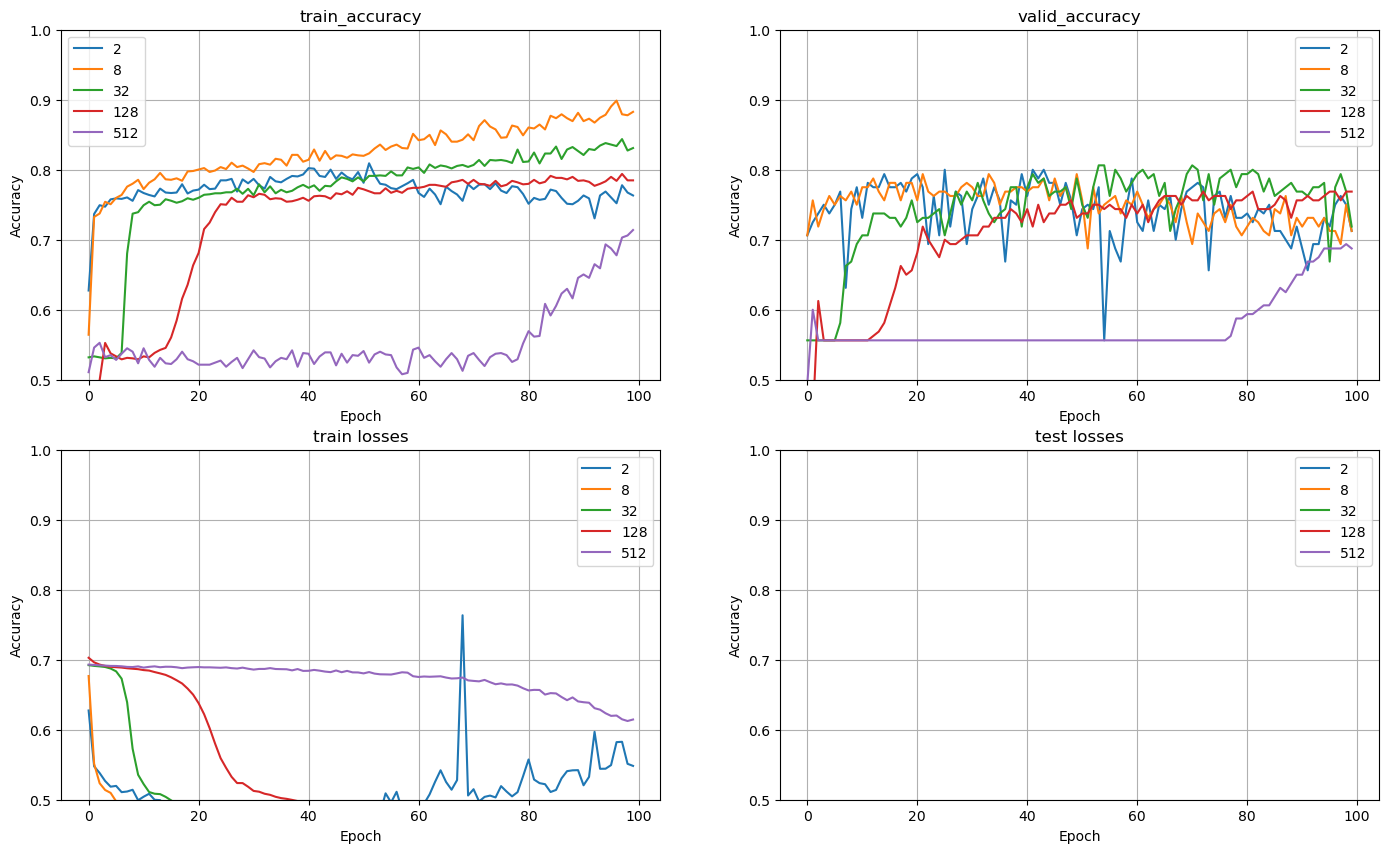

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(17, 10))
ax = ax.flatten()
print(ax)
ax[0].plot(train_accuracy)
ax[0].set_title("train_accuracy")

ax[1].plot(valid_accuracy)
ax[1].set_title("valid_accuracy")

ax[2].plot(train_losses)
ax[2].set_title("train losses")

ax[3].plot(test_losses)
ax[3].set_title("test losses")

for i in range(4):
    ax[i].legend(batch_sizes)
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Accuracy")
    ax[i].set_ylim([0.5, 1.0])  
    ax[i].grid()



In [52]:
print(test_losses)

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1.